In [1]:
import ollama
# llm = "qwen2.5"

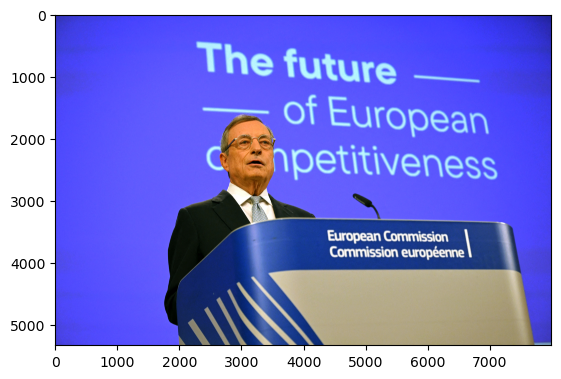

In [2]:
from matplotlib import image as pltimg, pyplot as plt

image_file = "res/draghi.jpeg"

plt.imshow(pltimg.imread(image_file))
plt.show()

In [3]:
res = ollama.generate(model="llava",
                prompt="describe the image",
                images=[image_file])["response"]
print(res)

 The image is a photograph of a man standing at a lectern, giving a speech. He appears to be an older gentleman dressed in formal attire, which includes a suit and tie. Behind him, there's a banner with text on it, although the resolution makes some of the words difficult to read clearly. The visible part of the banner reads "THE FUTURE OF EUROPEAN COMPETITIVENESS."

The setting suggests an indoor event, possibly a conference or presentation, as indicated by the stage and the formal dress code suggested for the speaker. The background is nondescript with no additional details that provide context about the location or the specific event. 


In [4]:
def process_image(path: str) -> str:
    return ollama.generate(model="llava", prompt="describe the image", images=[path])["response"]

tool_process_image = {'type':'function', 'function':{
    'name': 'process_image',
    'description': 'Load an image for a given path and describe what you see',
    'parameters': {'type': 'object',
                   'required': ['path'],
                   'properties': {
                       'path': {'type':'str', 'description':'the path of the image'}
}}}}

## test
process_image(path=image_file)

' The image is a photograph of a man giving a speech or presentation at an event. He is standing behind a lectern and is wearing a suit with a white shirt and a patterned tie. The man appears to be middle-aged, has short graying hair, and is smiling as he looks upwards towards the camera.\n\nIn front of him on a blue podium is a sign that reads "THE FUTURE OF EUROPEAN COMPETITIVENESS." This suggests that the event is related to European economic policy or strategies. The man\'s speech or presentation seems to be focused on this topic, as indicated by the text and his attire.\n\nThe background includes a purple wall with some text that is not entirely legible due to the image\'s resolution, but it appears to contain a logo of the European Union and possibly other elements related to the event. The overall style of the photograph seems to be taken during a formal occasion or conference. '

In [5]:
# pip install wikipedia==1.4.0
## 실습에서는 버전을 제외하고 실행( 당시 최신 버전이 1.4.0 이여서 해당 버전이 설치됨
from langchain_community.tools import WikipediaQueryRun
from langchain_community.utilities import WikipediaAPIWrapper

def search_wikipedia(query:str) -> str:
    return WikipediaQueryRun(api_wrapper=WikipediaAPIWrapper()).run(query)

tool_search_wikipedia = {'type':'function', 'function':{
    'name': 'search_wikipedia',
    'description': 'Search on Wikipedia by passing some keywords',
    'parameters': {'type': 'object',
                   'required': ['query'],
                   'properties': {
                       'query': {'type':'str', 'description':'The input must be short keywords, not a long text'}
}}}}

## test
search_wikipedia(query="draghi")

/opt/conda/lib/python3.11/site-packages/wikipedia/wikipedia.py:389: GuessedAtParserWarning: No parser was explicitly specified, so I'm using the best available HTML parser for this system ("html.parser"). This usually isn't a problem, but if you run this code on another system, or in a different virtual environment, it may use a different parser and behave differently.

The code that caused this warning is on line 389 of the file /opt/conda/lib/python3.11/site-packages/wikipedia/wikipedia.py. To get rid of this warning, pass the additional argument 'features="html.parser"' to the BeautifulSoup constructor.

  lis = BeautifulSoup(html).find_all('li')


'Page: Mario Draghi\nSummary: Mario Draghi  (Italian: [ˈmaːrjo ˈdraːɡi]; born 3 September 1947) is an Italian politician, economist, academic, banker, statesman, and civil servant, who served as the prime minister of Italy from 13 February 2021 to 22 October 2022. Prior to his appointment as prime minister, he served as the president of the European Central Bank (ECB) between 2011 and 2019. Draghi was also the chair of the Financial Stability Board between 2009 and 2011, and governor of the Bank of Italy between 2006 and 2011.\nAfter a lengthy career as an academic economist in Italy, Draghi worked for the World Bank in Washington, D.C., throughout the 1980s, and in 1991 returned to Rome to become director general of the Italian Treasury. He left that role after a decade to join Goldman Sachs, where he remained until his appointment as governor of the Bank of Italy in 2006. His tenure as Governor coincided with the 2008 Great Recession, and in the midst of this he was selected to becom

In [6]:
prompt = '''
You are a photographer that analyzes and describes images in details.
'''
messages_1 = [{"role":"system", "content":prompt}]

In [7]:
prompt = '''
You are a detective. You read the image description provided by the photographer, and you search Wikipedia to understand when and where the picture was taken.
'''
messages_2 = [{"role":"system", "content":prompt}]

In [17]:
def use_tool(agent_res:dict, dic_tools:dict) -> dict:
    ## 기본값 설정
    res = agent_res["message"].get("content", "")
    t_name, t_inputs = '', ''
    
    ## 도구 사용 여부 확인 (딕셔너리 키로 확인)
    if "tool_calls" in agent_res["message"]:
    # if "tool_calls" in dir(agent_res["message"]):
        for tool in agent_res["message"]["tool_calls"]:
            t_name, t_inputs = tool["function"]["name"], tool["function"]["arguments"]
            
            if f := dic_tools.get(t_name):
                ### calling tool
                print('🔧 >', f"\x1b[1;31m{t_name} -> Inputs: {t_inputs}\x1b[0m")
                ### tool output
                t_output = f(**tool["function"]["arguments"])
                print(t_output)
                ### final res
                res = t_output
            else:
                print('🤬 >', f"\x1b[1;31m{t_name} -> NotFound\x1b[0m")

    return {'res':res, 'tool_used':t_name, 'inputs_used':t_inputs}

In [18]:
dic_tools = {'process_image':process_image,
             'search_wikipedia':search_wikipedia}

📷 > give me the image to analyze: res/draghi.jpeg


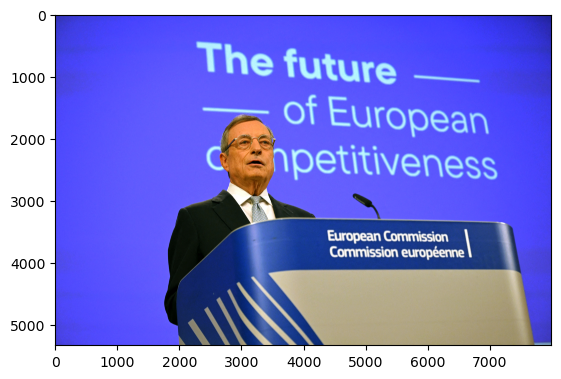

🔧 > process_image -> Inputs: {'path': 'res/draghi.jpeg'}
 The image is a photograph taken at an event. In the foreground, there is a man standing at a podium, giving a speech or presentation. He appears to be wearing formal attire, including a suit and tie. Behind him, there's a sign that reads "THE FUTURE OF EUROPEAN COMPETITIVENESS" in capital letters. The background is otherwise indistinct due to the blur, suggesting it was taken with a shallow depth of field or a long exposure time.

The photograph has a watermark or overlay text that reads "European Commission," indicating that this image may have been taken during an event related to the European Union's policies on competitiveness. The focus and composition of the photograph suggest it was taken in an indoor setting, possibly at a conference or seminar. 
👽📷 >  The image is a photograph taken at an event. In the foreground, there is a man standing at a podium, giving a speech or presentation. He appears to be wearing formal attir

In [23]:
while True:
    ## user input
    try:
        q = input('📷 > give me the image to analyze:')
    except EOFError:
        break
    if q == "quit":
        break
    if q.strip() == "":
        continue
    messages_1.append({"role":"user", "content":q})

    plt.imshow(pltimg.imread(q))
    plt.show()

    ## Agent 1
    agent_res = ollama.chat(model="mistral-small3.1",
                tools=[tool_process_image],
                messages=messages_1)
    dic_res = use_tool(agent_res, dic_tools)
    res, tool_used, inputs_used = dic_res["res"], dic_res["tool_used"], dic_res["inputs_used"]

    print("👽📷 >", f"\x1b[1;30m{res}\x1b[0m")
    messages_1.append({"role":"assistant", "content":res})

    ## Agent 2
    messages_2.append({"role":"system", "content":"-Picture: "+res})

    agent_res = ollama.chat(model="qwen2.5",
                tools=[tool_search_wikipedia],
                messages=messages_2)
    dic_res = use_tool(agent_res, dic_tools)
    res, tool_used, inputs_used = dic_res["res"], dic_res["tool_used"], dic_res["inputs_used"]

    if tool_used == "search_wikipedia":
        messages_2.append({"role":"system", "content":"-Wikipedia: "+res})
        agent_res = ollama.chat(model=llm,
                tools=[],
                messages=messages_2)
        dic_res = use_tool(agent_res, dic_tools)
        res, tool_used, inputs_used = dic_res["res"], dic_res["tool_used"], dic_res["inputs_used"]
    else:
        messages_2.append({"role":"assistant", "content":res})

    print("👽📖 >", f"\x1b[1;30m{res}\x1b[0m")
    break